<a href="https://colab.research.google.com/github/abdulrahman0700/Industrial_Predictive_Maintenance_Elevvo_internship/blob/main/Notebooks/03_Construct_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PACE Stages**

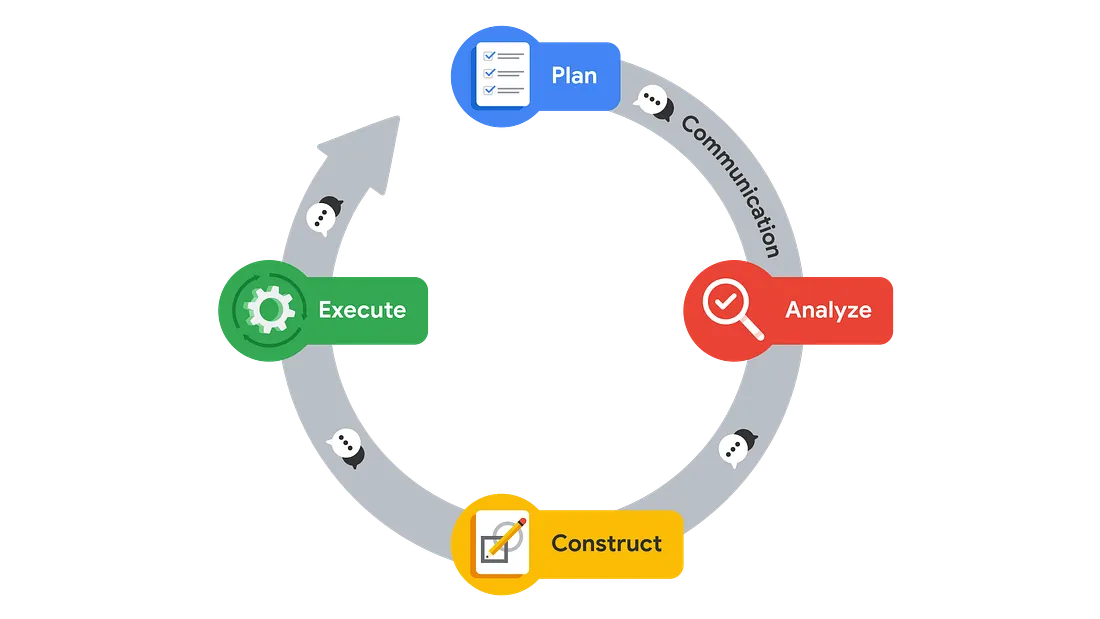

#paCe : Construct Stage

- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data

## Recall model assumptions

**XGBoosts/LightGBM model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No data leakage
- Features are properly encoded
- Missing values are handled appropriately
- No severe overfitting
- Sufficient data and class representation
- Class imbalance is considered
- Train/test data are representative

### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?


- ### Do you notice anything odd ?

> I noticed that the model performs very high performance Despite the Imbalance data on Failure and No-Failure Separation case and High Performance here mean that the F1-Socre is above 0.50

> I noticed that the model performs very low performance because F1-Score is 0 ! on "Random Type Failures" on predicting the Type of Failure

- ### Which independent variables did you choose for the model and why?
> I selected variables that had a meaningful relationship with "Machine Failure" variable based on EDA , Features such as
  - Air_temperature_[K]
  - Process_temperature_[K]
  - Rotational_speed_[rpm]
  - Torque_[Nm]
  - Tool_wear_[min]
  - Power[P]
- strain
- Temperature_difference

- ### Are each of the assumptions met?
> I checked that the target was correctly defined, observations were appropriate, there was no data leakage, features were properly encoded, missing values were handled, class imbalance was considered, and the model did not significantly overfit the training data.

- ### How well does your model fit the data ?
>For XGBoost/LightGBM, evaluate using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

Because our problem involves predicting Machine Failure and Type of Machine Failure , pay particular attention to:
- Recall and F1-Score for `Machine_Failure = 1`
- Recoll and F1-Score for `TWF , HWF ,PWF, OSF , RNF = 1`



- ### Can you improve it? Is there anything you would change about the model?
> we can  use cross-validation and early stopping to improve generalization.

- ### What resources do you find yourself using as you complete this stage? (Make sure to include the links.)

- XGBoost documentation "https://xgboost.readthedocs.io/en/stable/"
- LightGBM documentation "https://lightgbm.readthedocs.io/en/stable/"
- Scikit-learn documentation "http://scikit-learn.org/stable/"

- ### Do you have any ethical considerations in this stage?
> No , there is no Ethical consideration

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.


**Our Main Challenge is to prevent the machine from failing and for doing this we need to predict when the machine fails and by indetifiying the Failure Type , We will know exactly the certain values of the Feature (Torgue , Rotational speed and ete) that causes the Fail**

### Identify the types of models most appropriate for this task.


**Classification Models**

In [341]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder , OneHotEncoder, MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split ,GridSearchCV
import lightgbm as lgm
import xgboost
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTENC ,SMOTE
from sklearn.metrics import confusion_matrix ,ConfusionMatrixDisplay , accuracy_score, f1_score , recall_score , precision_score , classification_report
from imblearn.pipeline import Pipeline
import joblib
import pickle

1. Predicting the when the machine can fail on specifics values

2. Predicting the Type Of Machine Failure(in notebook 03_construct_v2)

# 1. Predicting the when the machine can fail on specifics values

In [342]:
df = pd.read_csv("df_cleaned.csv",index_col=0)

In [343]:
df.head(5)

,Product_ID,Type,Air_temperature_[K],Process_temperature_[K],Rotational_speed_[rpm],Torque_[Nm],Tool_wear_[min],Machine_failure,Tool_Wear_Failure[TWF],Heat_Dissipation_Failure[HDF],Power_Failure[PWF],Overstrain_Failure[OSF],Random_Failures[RNF]
UDI,,,,,,,,,,,,,
1,L70598,L,297.9,307.1,1525,20.3,238,0,0,0,0,0,0
2,H76399,H,298.6,307.8,1384,32.3,249,0,0,0,0,0,0
3,M37684,M,305.0,314.1,1958,36.3,67,0,0,0,0,0,0
4,L78591,L,300.3,309.7,1009,46.8,248,1,0,0,0,1,0
5,L87722,L,300.7,311.6,1863,38.6,133,0,0,0,0,0,0


# Feature Engineering

In [344]:
df['Power[W]'] = round(df['Torque_[Nm]'] * (df['Rotational_speed_[rpm]'] * (2 * np.pi / 60)),2)
df['strain'] = df['Tool_wear_[min]'] * df['Torque_[Nm]']
df['Temperature_difference'] = df['Process_temperature_[K]'] - df['Air_temperature_[K]']

In [345]:
df.sample(10)

,Product_ID,Type,Air_temperature_[K],Process_temperature_[K],Rotational_speed_[rpm],Torque_[Nm],Tool_wear_[min],Machine_failure,Tool_Wear_Failure[TWF],Heat_Dissipation_Failure[HDF],Power_Failure[PWF],Overstrain_Failure[OSF],Random_Failures[RNF],Power[W],strain,Temperature_difference
UDI,,,,,,,,,,,,,,,,
4232,L22693,L,302.7,311.3,1690,26.4,184,0,0,0,0,0,0,4672.18,4857.6,8.6
7421,L63986,L,301.8,311.5,1629,54.3,78,0,0,0,0,0,0,9262.95,4235.4,9.7
9475,H44833,H,301.5,313.1,1534,38.0,227,0,0,0,0,0,0,6104.32,8626.0,11.6
9194,M69117,M,300.5,312.5,1613,40.6,100,0,0,0,0,0,0,6857.87,4060.0,12.0
8093,L86902,L,303.6,313.6,1438,34.6,165,0,0,0,0,0,0,5210.31,5709.0,10.0
6509,M11085,M,298.3,309.4,1715,34.8,127,0,0,0,0,0,0,6249.88,4419.6,11.1
4637,L70200,L,297.3,306.6,1611,43.8,34,0,0,0,0,0,0,7389.21,1489.2,9.3
344,L16955,L,300.5,310.8,1719,27.1,156,0,0,0,0,0,0,4878.36,4227.6,10.3
9654,L23979,L,303.9,314.3,1504,47.1,225,0,0,0,0,0,0,7418.18,10597.5,10.4


In [346]:
df_copy_machine_failure = df.copy()
# df_copy_machine_type_failure = df.copy()

In [347]:
df_copy_machine_failure.drop(columns=["Product_ID"],inplace=True)

In [348]:
df_copy_machine_failure.sample(5)

,Type,Air_temperature_[K],Process_temperature_[K],Rotational_speed_[rpm],Torque_[Nm],Tool_wear_[min],Machine_failure,Tool_Wear_Failure[TWF],Heat_Dissipation_Failure[HDF],Power_Failure[PWF],Overstrain_Failure[OSF],Random_Failures[RNF],Power[W],strain,Temperature_difference
UDI,,,,,,,,,,,,,,,
6884,L,299.1,310.1,1621,40.9,119,0,0,0,0,0,0,6942.80,4867.1,11.0
4058,L,300.5,310.9,1741,32.0,197,0,0,0,0,0,0,5834.15,6304.0,10.4
620,M,299.6,310.5,1552,44.7,200,0,0,0,0,0,0,7264.87,8940.0,10.9
140,H,299.9,308.7,1862,29.1,148,0,0,0,0,0,0,5674.16,4306.8,8.8
117,M,300.6,310.2,1690,39.7,80,0,0,0,0,0,0,7025.96,3176.0,9.6


In [349]:
df_copy_machine_failure.rename(columns={"Air_temperature_[K]":"Air_temperature__K",
                                             "Process_temperature_[K]":"Process_temperature__K",
                                             "Rotational_speed_[rpm]":"Rotational_speed__rpm",
                                             "Torque_[Nm]":"Torque__Nm",
                                             "Tool_wear_[min]":"Tool_wear__min",
                                             "Power[W]":"Power_W",
                                             "Tool_Wear_Failure[TWF]":"Tool_Wear_Failure_TWF",
                                             "Heat_Dissipation_Failure[HDF]":"Heat_Dissipation_Failure_HDF",
                                             "Power_Failure[PWF]":"Power_Failure_PWF",
                                             "Overstrain_Failure[OSF]":"Overstrain_Failure_OSF",
                                             "Random_Failures[RNF]":"Random_Failures_RNF"},inplace=True)

In [350]:
X = df_copy_machine_failure.drop(columns=["Machine_failure","Tool_Wear_Failure_TWF","Heat_Dissipation_Failure_HDF","Power_Failure_PWF","Overstrain_Failure_OSF","Random_Failures_RNF"])
y = df_copy_machine_failure["Machine_failure"]

In [351]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [352]:
numerical_data_mf = X.select_dtypes(include=np.number)
categorical_data_mf = X.select_dtypes(include="object")

In [353]:
numerical_feature = Pipeline(steps=[
    ("scaler",StandardScaler())
])


In [354]:
categorical_feature = Pipeline(steps=[
    ("encoder",OneHotEncoder(handle_unknown='ignore'))
])

In [355]:
Processor = ColumnTransformer(transformers=[
    ("num",numerical_feature,numerical_data_mf.columns),
    ("cat",categorical_feature,categorical_data_mf.columns)
])

In [356]:
models = [LogisticRegression(),RandomForestClassifier(),lgm.LGBMClassifier(),XGBClassifier()]
models_names = ["LogisticRegression","RandomForestClassifier","LGBMClassifier","XGBClassifier"]

In [357]:
pipes = [Pipeline(steps=[("processor",Processor),("model",model)]) for model in models]
# pipes[3].get_params()

In [358]:
scale_pos_weight = len(df_copy_machine_failure[df_copy_machine_failure['Machine_failure']==0])//len(df_copy_machine_failure[df_copy_machine_failure['Machine_failure']==1])
scale_pos_weight

14

In [359]:

params=[{"model__multi_class":["multinomial",'ovr','deprecated'],"model__penalty":['l2','l1'],"model__class_weight":["balanced"],"model__max_iter":[1000]},

        {"model__n_estimators":[200,300,500],"model__criterion":['gini','entropy'],"model__class_weight":["balanced","balanced_subsample"],"model__random_state":[42]} ,

        {"model__n_estimators":[100,300,500],"model__boosting_type":['gbdt','goss','dart','rf'],"model__learning_rate":[0.05,0.01],"model__importance_type":['split','gain'],"model__class_weight":["balanced"]},

        {"model__n_estimators":[100,200,300],"model__learning_rate":[0.01,0.05,0.1],"model__booster":['gbtree','gblinear','dart'],"model__scale_pos_weight":[scale_pos_weight]}
        ]

In [360]:
grids = [GridSearchCV(estimator=pipes[i],param_grid=params[i],cv=2) for i in range(len(pipes))]

In [361]:
for i in range(len(grids)):
    grids[i].fit(X_train,y_train)

    print(f"model {models_names[i]} has {grids[i].best_score_}")

model LogisticRegression has 0.80825
model RandomForestClassifier has 0.981875
model LGBMClassifier has 0.981875
model XGBClassifier has 0.978


In [362]:
f1_scores = [f1_score(y_test,grids[i].predict(X_test)) for i in range(len(grids))]
recall_scores = [recall_score(y_test,grids[i].predict(X_test)) for i in range(len(grids))]
precision_scores = [precision_score(y_test,grids[i].predict(X_test)) for i in range(len(grids))]
Testing_accuracy = [accuracy_score(y_test,grids[i].predict(X_test)) for i in range(len(grids))]
Training_accuracy = [accuracy_score(y_train,grids[i].predict(X_train)) for i in range(len(grids))]

FDR = [1 - precision_scores[i] for i in range(len(precision_scores))]

metrics_models_table = pd.DataFrame({"models":models_names,
                                     "f1_scores":f1_scores,
                                     "recall_scores":recall_scores,
                                     "precision_scores":precision_scores,
                                     "Testing_accuracy":Testing_accuracy,
                                     "Training_accuracy":Training_accuracy,
                                     "FDR":FDR})

metrics_models_table

,models,f1_scores,recall_scores,precision_scores,Testing_accuracy,Training_accuracy,FDR
0,LogisticRegression,0.356688,0.817518,0.228106,0.7980,0.807,0.771894
1,RandomForestClassifier,0.883534,0.802920,0.982143,0.9855,1.000,0.017857
2,LGBMClassifier,0.875000,0.817518,0.941176,0.9840,1.000,0.058824
3,XGBClassifier,0.846154,0.802920,0.894309,0.9800,1.000,0.105691


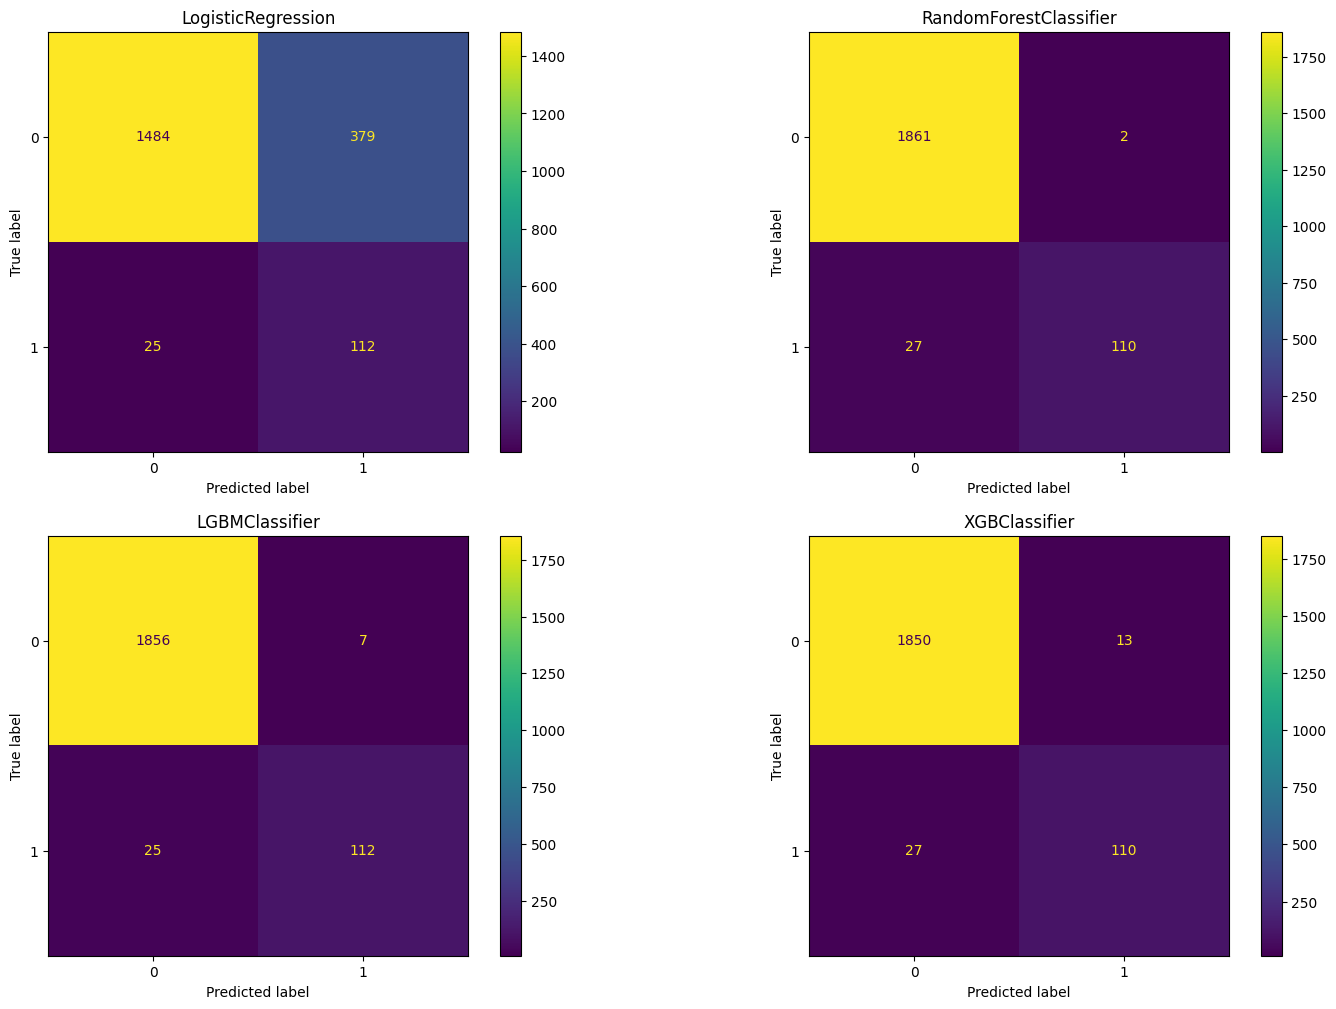

In [363]:
fig , ax = plt.subplots(2,2,figsize=(18,12))
for i in range(len(grids)):
  ax[i//2,i%2].set_title(f"{models_names[i]}")
  ConfusionMatrixDisplay(confusion_matrix(y_test,grids[i].predict(X_test))).plot(ax=ax[i//2,i%2])
plt.show()

In [364]:
reports  = [classification_report(y_test, grids[i].predict(X_test), target_names=['Non_Failure','Failure'], zero_division=0,output_dict=True) for i in range(len(grids)) ]

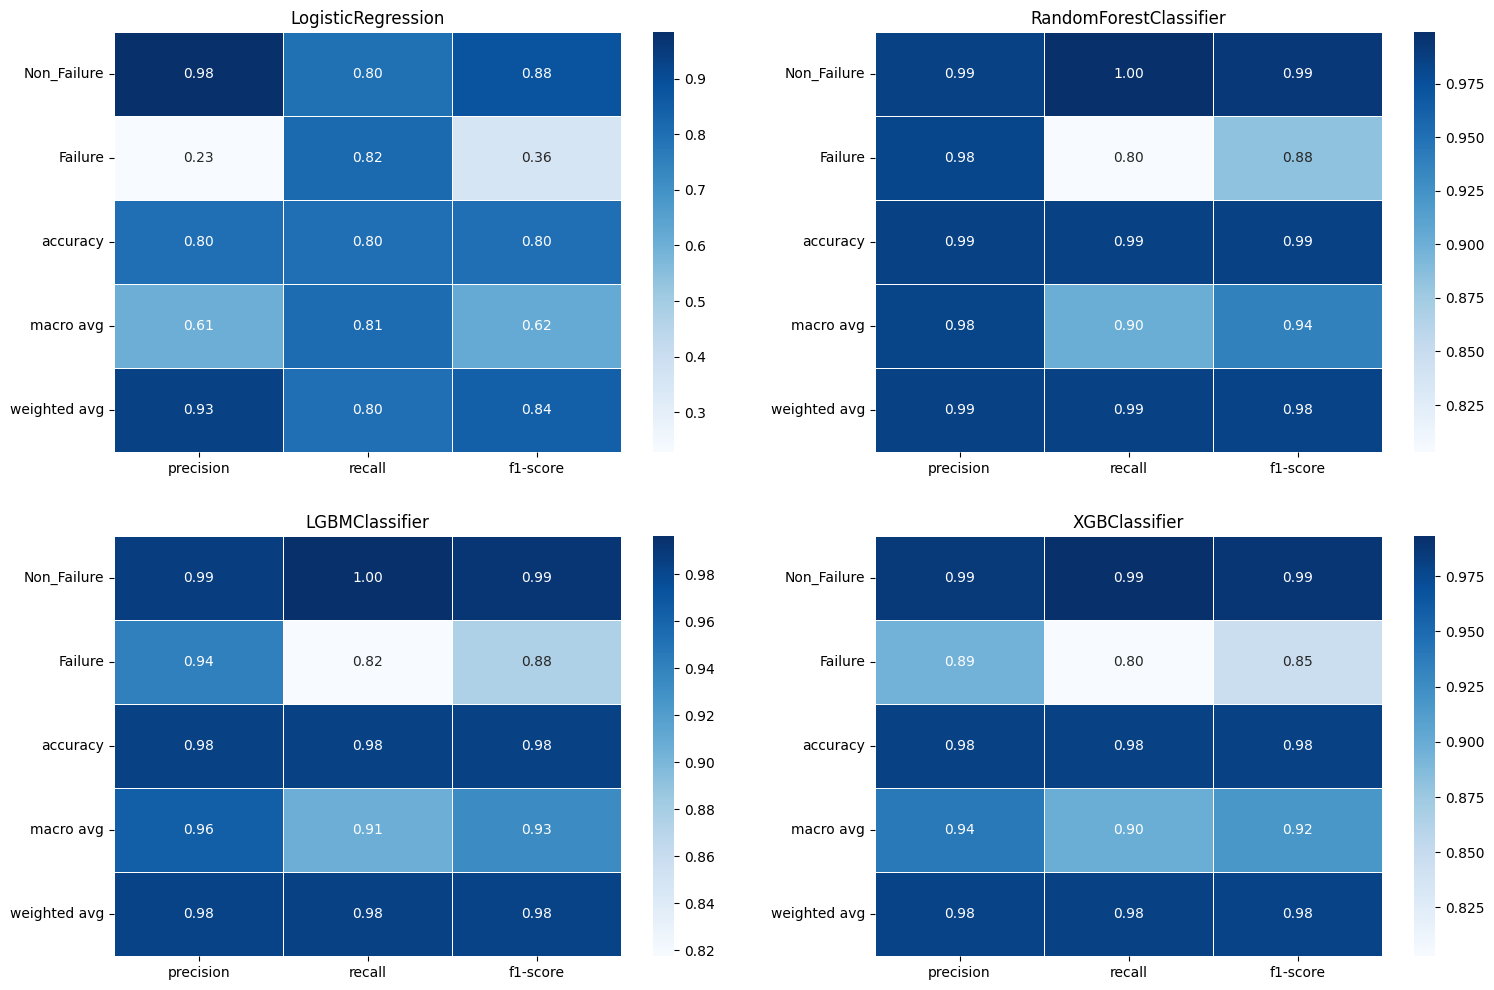

In [365]:
figure , axis = plt.subplots(2,2,figsize=(18,12))
for j in range(len(reports)):
  report_df = pd.DataFrame(reports[j]).transpose()

# Remove support because it's on a different scale
  report_df = report_df.drop(columns=["support"])

  sns.heatmap(
    report_df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    ax=axis[j//2,j%2]
  )
  axis[j//2,j%2].set_title(f"{models_names[j]}")
plt.show()

In [366]:
joblib.dump(grids[2], "lgbm_model_failure.joblib")

['lgbm_model_failure.joblib']

In [368]:
gbm_model = grids[2].fit(X_train,y_train)

In [382]:
fitted_processor = gbm_model.best_estimator_.named_steps['processor']

In [383]:
feature_names = fitted_processor.get_feature_names_out()

In [384]:
transformed_X = fitted_processor.transform(X_test)

In [385]:
if hasattr(transformed_X, "toarray"):
    transformed_X = transformed_X.toarray()

In [386]:
transformed_X_df = pd.DataFrame(transformed_X, columns=feature_names, index=X_test.index)


In [387]:
explainer = shap.TreeExplainer(gbm_model.best_estimator_.named_steps['model'])
shap_values = explainer(transformed_X_df)

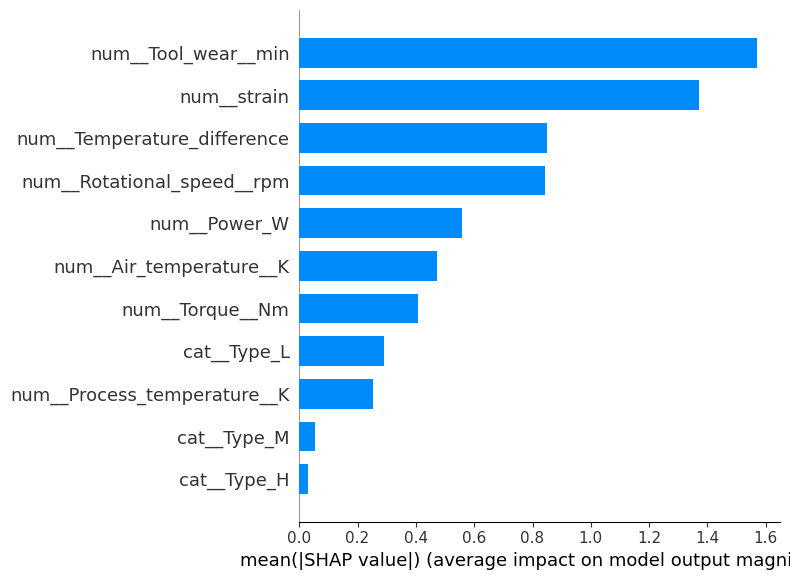

In [388]:
shap.summary_plot(shap_values, transformed_X_df, plot_type="bar")

In [398]:
shap.initjs()

shap.force_plot(explainer.expected_value, shap_values.values[0, :],transformed_X_df.iloc[0,:])


In [392]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values.values[:1000,:],transformed_X_df.iloc[:1000,:])

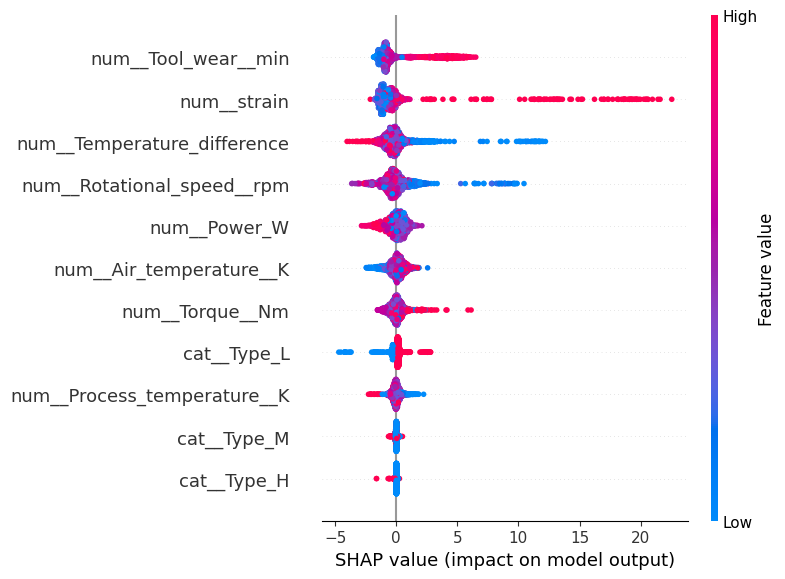

In [393]:
shap.summary_plot(shap_values, transformed_X_df)